# Email Graph Network Analysis

This project analyzes my work email inbox (MBOX) encompassing several thousand messages sent and received since November 2025. The dataset covers a critical period of planning and execution for an organization-wide ERP system implementation. To maintain privacy, all names and email addresses will be anonymized.

<br>

The network is modeled as a directed, weighted graph where nodes represent individual participants (senders and recipients). The edges represent the flow of email from sender to recipient, weighted by exchange frequency. This allows for the differentiation between casual correspondence and the high-density collaborative communications characteristic of a major systems implementation.

<br>

We hope to identify key individuals that can support or act as communication bottlenecks in the project.

### Environment Setup & Drive Mounting

We configure and connect to the Google Colab instance and map to th drive folder where mailbox file is stored. This is an MBOX file type exported from Google Workspace.

In [1]:
import os
import pandas as pd
import warnings
from google.colab import drive

# Configure Global Settings
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 500)

# Mount the Google Drive container to the local Colab instance
drive.mount('/content/drive', force_remount=True)

# Define  Working Directory
data_path = "/content/drive/MyDrive/Data620"
os.chdir(data_path)

# Validate the directory
print(f"Current Working Directory: {os.getcwd()}")

Mounted at /content/drive
Current Working Directory: /content/drive/MyDrive/MSDS/Data620


### Create Graph Network Topology from Mailbox File

This code extracts the raw email data and organizes and structures it into a network graph. Each person (node) is a point and every email sent creates a link between them (edge). It measures the strength of these relationships by assigning a higher value to direct emails and a lower value to those where someone was simply copied (Cc'd or Bcc'd).

This results in a Graph: **482 nodes, 1102 edges.**

In [2]:
import mailbox
import os
import networkx as nx
from email.utils import getaddresses

def extract_valid_emails(headers):
    """
    Parses and normalizes email addresses from raw MBOX header strings.
    """
    return [
        addr[1].lower()
        for header in headers if header
        for addr in getaddresses([str(header)]) if addr[1] ]

#  Initialize the Directed Graph and Data Source
mbox_file = os.path.join(data_path, 'SIS.mbox')
mbox = mailbox.mbox(mbox_file)

# Instantiate an empty directed graph
G = nx.DiGraph()

# Iteratively Parse Messages
for message in mbox:
    # Extract the sender
    senders = extract_valid_emails([message['From']])
    if not senders:
        continue

    sender = senders[0]

    # Define recipient weight parameters (To = 1.0, Cc/Bcc = 0.5)
    routing_rules = [
        (message.get_all('To', []), 1.0),
        (message.get_all('Cc', []) + message.get_all('Bcc', []), 0.5) ]

    #  Process Edges and their  weights
    for headers, incremental_weight in routing_rules:
        for recipient in extract_valid_emails(headers):
            edge_data = G.get_edge_data(sender, recipient, default={'weight': 0.0})
            current_weight = edge_data.get('weight', 0.0)

            # Add the edge weights
            G.add_edge(sender, recipient, weight=current_weight + incremental_weight)

# Validate the network graph construction
print("Network Extraction Complete.")
print(f"Original Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

Network Extraction Complete.
Original Graph: 482 nodes, 1102 edges.


### Network Pruning

This code refines the network by removing self-sent messages and filtering out weak or isolated connections to focus on the most significant relationships. By stripping away minor interactions, the network's structure focuses on  the primary hubs of activity and are easier to identify.

This results in a Pruned Graph: **169 nodes, 690 edges.**

In [3]:
import networkx as nx
import pandas as pd
import os

# Eliminate Self-Loops
G.remove_edges_from(list(nx.selfloop_edges(G)))

# Filter the edge list to only retain connections with a weight of 1.0 or higher.
weak_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < 1.0]
G.remove_edges_from(weak_edges)

# 3. Prune Pendants and Isolates
low_degree_nodes = [node for node, degree in G.degree() if degree <= 1]
G.remove_nodes_from(low_degree_nodes)

print(f"Network Pruning Complete.")
print(f"Pruned Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

Network Pruning Complete.
Pruned Graph: 169 nodes, 690 edges.


### Create & Export Node  Management File

This code creates a master list of all the unique people identified in the email network and assigns each one a numeric ID. It then saves this list as a separate file so the job role categorizes can be added and reimported.

In [4]:
import pandas as pd
import os

# Map Attributes
node_data = [
    {'Email': email, 'Anonymized_ID': idx, 'Job_Role': 'Unknown'}
    for idx, email in enumerate(G.nodes(), start=100)]

# Convert into a Pandas DataFrame
df_nodes = pd.DataFrame(node_data)

#  Export to path for manual updates
csv_path = os.path.join(data_path, 'node_management.csv')
df_nodes.to_csv(csv_path, index=False)

# Validate the export process
print(f"Node Management file successfully exported to: {csv_path}")

Node Management file successfully exported to: /content/drive/MyDrive/Data620/node_management.csv


### Network Graph Anonymization & Attribute Mapping

This code updates the job role to each person. We anonymize the original email address by mapping the email address to a unique integer ID and the job role category.

In [5]:
import pandas as pd
import networkx as nx
from google.colab import auth
from google.auth import default
import gspread

#  Authenticate to Google Drive
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

#  Parse the Node Management Sheet
worksheet = gc.open('node_management').sheet1
df_updated = pd.DataFrame(worksheet.get_all_records())

# Enforce integer typing
df_updated['Anonymized_ID'] = pd.to_numeric(df_updated['Anonymized_ID'], errors='coerce').astype(int)

#  Construct Attribute Dictionaries
role_mapping = df_updated.set_index('Email')['Job_Role'].to_dict()
id_mapping = df_updated.set_index('Email')['Anonymized_ID'].to_dict()
nx.set_node_attributes(G, role_mapping, 'Job_Role')

# Relabel the node from emails to  integers.
G_anonymized = nx.relabel_nodes(G, id_mapping)

# Validate successful anonymization
print(f"\nFinal Anonymized Graph: {G_anonymized.number_of_nodes()} nodes, {G_anonymized.number_of_edges()} edges.")
print("Sample Node Data:", list(G_anonymized.nodes(data=True))[:2])


Final Anonymized Graph: 169 nodes, 690 edges.
Sample Node Data: [(100, {'Job_Role': 'External'}), (101, {'Job_Role': 'Self'})]


### Export Gephi Graph FIle

This code saves the final anonymized network into the Gephi file format.  We later visualize this file in Gephi.

In [6]:
import os
import networkx as nx

#  Define the endpoint path
export_path = os.path.join(data_path, "core_network_anonymized.gexf")

#  Write the gexf file
nx.write_gexf(G_anonymized, export_path)

# Validate the successful export
print(f"Ready for Gephi. File exported to: {export_path}")

Ready for Gephi. File exported to: /content/drive/MyDrive/Data620/core_network_anonymized.gexf


## Ego Network Visualization (Gephi)

The ego network consists of a single central individual (me) and everyone I have directly emailed or received emails from (the "alters"). This specific visualization highlights my immediate email communication orbit showing the direct strength and direction of the email interations interactions before considering how my colleagues interact with one another.

<br>

As the ego, I am  a singular point of failure or a universal neighbor, creating a star  topology that masks the underlying community structure since all communications flow through me in this my email inbox.

In [7]:
from IPython.display import Image, display

# Define the URL
img_url = "https://raw.githubusercontent.com/johnnydrodriguez/data620/084c977185d6c0c794a14ffc619aa1a40655fc30/email_ego_network.png"

# Display the image
display(Image(url=img_url, width=800))

## Alter Network Visualization (Gephi)

The alter network represents the web of connections that exist between my contacts. it depicts  how my colleagues interact with one another independent of my involvement. By removing myself" (the ego), I eliminated the central hub that artificially inflated connectivity. Removal of the ego allows centrality measures to reveal the true influencers and information brokers within the group.

<br>

When the ego is removed, the betweenness centrality of the remaining alters becomes a more accurate reflection of their roles in the network; without me as the default intermediary, we can see which alters possess the highest structural holes and who facilitates the flow of information across the remaining edges.

<br>

Once removed, the alters visualization shows changes to connectivity. While most changes are isolates that form because I no longer connect these individuals, there is also a sizeable cluster of nodes which is completely disconnected from the core with my removal.

In [8]:
from IPython.display import Image, display

# Define the  URL
img_url = "https://raw.githubusercontent.com/johnnydrodriguez/data620/084c977185d6c0c794a14ffc619aa1a40655fc30/email_alter_network.png"

# Display the image
display(Image(url=img_url, width=800))

### Isolate the Alter Network For Centrality Metrics

This code creates a version of the network graph that excludes me (the ego) By removing this central hub, we can more clearly see how my colleagues interact with each other and calculate the resulting centrality metrics.


In [9]:
import networkx as nx
import pandas as pd

#  Isolate the Alter Network
G_alter = G_anonymized.copy()

# Identify nodes where the 'Job_Role' attribute is 'Self"
ego_nodes = [
    node for node, attributes in G_alter.nodes(data=True)
    if attributes.get('Job_Role') == 'Self']

# Extract the ego nodes to for the alter sub graph
G_alter.remove_nodes_from(ego_nodes)

# Validate the transformation
print(f"Nodes removed: {len(ego_nodes)}")
print(f"Alter Network Nodes: {G_alter.number_of_nodes()}")
print(f"Alter Network Edges: {G_alter.number_of_edges()}")

Nodes removed: 5
Alter Network Nodes: 164
Alter Network Edges: 374


## Alter Centrality Calculations and Interpretation of Results

This code calcultes four centrality scores for every person involved. It then ranks everyone to reveal who holds the most social power, who acts as a critical information bridge, and who is most efficiently positioned to reach the rest of the group.

<br>

**Manager 129** is the undisputed super-hub of this network. This individual ranks #1 across every single metric, which indicates they are likely the primary information gatekeeper for the entire group.

Interestingly, **External 140 and 183** appear in the top lists for both Influence (Eigenvector) and Bridging (Betweenness), suggesting that certain external partners are deeply integrated into the my network, more so than other managers and executives.

In [10]:
# Compute Inverse Weights for Betweeness & Closeness
for u, v, data in G_alter.edges(data=True):
    weight = data.get('weight', 1.0)
    data['inverse_weight'] = 1.0 / weight

# Degree Centrality
deg_cent = nx.degree_centrality(G_alter)

# Calculate Betweeness and Closeness
bet_cent = nx.betweenness_centrality(G_alter, weight='inverse_weight', normalized=True)
clo_cent = nx.closeness_centrality(G_alter, distance='inverse_weight')

# Calculate Eigenvector Centrality
eig_cent = nx.eigenvector_centrality(G_alter, weight='weight', max_iter=1000)

# Consolidate Results
centrality_data = [
    {
        'Anonymized_ID': node,
        'Job_Role': G_alter.nodes[node].get('Job_Role', 'Unknown'),
        'Degree': deg_cent[node],
        'Betweenness': bet_cent[node],
        'Closeness': clo_cent[node],
        'Eigenvector': eig_cent[node]
    }
    for node in G_alter.nodes()]

df_metrics = pd.DataFrame(centrality_data)

# Output top nodes to validate
metrics = ['Degree', 'Betweenness', 'Closeness', 'Eigenvector']
for m in metrics:
    print(f"\nTop 5 Alters by {m} Centrality:")
    top_nodes = df_metrics.nlargest(5, m)[['Anonymized_ID', 'Job_Role', m]]
    print(top_nodes.to_string(index=False))


Top 5 Alters by Degree Centrality:
 Anonymized_ID  Job_Role   Degree
           129   Manager 0.460123
           133   Manager 0.245399
           136   Manager 0.239264
           140  External 0.220859
           106 Executive 0.171779

Top 5 Alters by Betweenness Centrality:
 Anonymized_ID  Job_Role  Betweenness
           129   Manager     0.145289
           133   Manager     0.044062
           140  External     0.030542
           183  External     0.028441
           106 Executive     0.023555

Top 5 Alters by Closeness Centrality:
 Anonymized_ID Job_Role  Closeness
           129  Manager   0.520256
           130    Staff   0.499710
           128  Manager   0.485092
           123  Manager   0.477781
           121  Manager   0.468734

Top 5 Alters by Eigenvector Centrality:
 Anonymized_ID Job_Role  Eigenvector
           129  Manager     0.681186
           130    Staff     0.339310
           183 External     0.269238
           128  Manager     0.267645
           140 E

## Categorical Job Role Centrality Calculation and Interpretation of Results

This code groups everyone by their job role to calculate the average centrality score for each department and then measures how much individuals within those groups differ from one another. It provides a view of which individuals are most active and whether that activity is shared equally or concentrated in just a few people.

<br>

The results show that **Managers** are the primary drivers of the network, holding the highest average scores for connection volume and bridging roles. However, the high scores for **Executives and External** partners in closeness suggest that while they email less frequently, they remain positioned to reach the entire organization quickly when needed.

<br>

We calculate the standard deviation to see if a group's influence is distributed evenly or if it's being driven by individual.  For **Managers**, the high standard deviation reveals a massive gap between a few highly active leaders and others who are much less connected.  This suggests that the organization influence relies heavily on specific individuals rather than the whole team within the Managers group.


In [11]:
#  Compute Expected Centrality Values (Mean) per Category
role_mean = df_metrics.groupby('Job_Role')[metrics].mean()
role_mean = role_mean.sort_values(by='Betweenness', ascending=False)

print("\nMean Centrality Measures Aggregated by Job Role:")
print(role_mean.to_string())

#  Compute Intragroup Variance (Standard Deviation)
role_variance = df_metrics.groupby('Job_Role')[metrics].std().fillna(0)

print("\nStandard Deviation of Centrality by Job Role:")
print(role_variance.to_string())


Mean Centrality Measures Aggregated by Job Role:
             Degree  Betweenness  Closeness  Eigenvector
Job_Role                                                
Manager    0.051065     0.006704   0.205753     0.046360
Executive  0.038344     0.002944   0.209195     0.029990
External   0.029745     0.002046   0.177899     0.032605
Staff      0.018486     0.000511   0.134184     0.011764
Service    0.012270     0.000143   0.076653     0.002351

Standard Deviation of Centrality by Job Role:
             Degree  Betweenness  Closeness  Eigenvector
Job_Role                                                
Executive  0.054652     0.008328   0.144593     0.068797
External   0.043003     0.007128   0.163115     0.069619
Manager    0.095542     0.025747   0.162179     0.126788
Service    0.019074     0.000515   0.144993     0.005400
Staff      0.025394     0.002455   0.142564     0.045460


## Correlation Plot of Centrality Metrics

There is a strong, linear correlation between Degree and Eigenvector centrality; the people with the most contacts are almost always the same ones connected to other high-power players.

<br>

The Betweenness plots show a distinct "L-shaped" pattern; most people have nearly zero bridging power, while only one or two extreme outliers (like node 129) act as the critical glue holding different parts of the network together.

<br>

The distribution for Closeness is unique because it is bimodal;  it suggests the network is split into two distinct groups: one that is deeply integrated and can reach everyone quickly, and another that is relatively isolated.

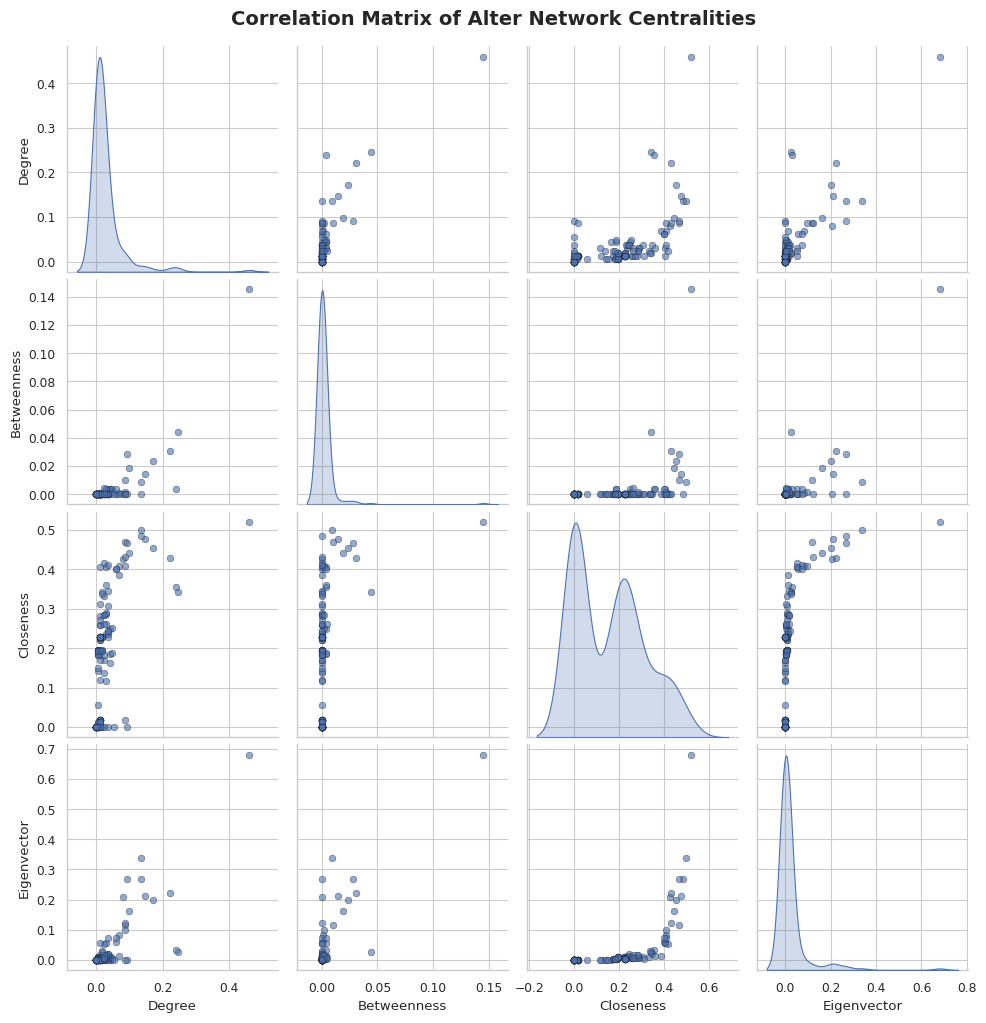

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
metrics = ['Degree', 'Betweenness', 'Closeness', 'Eigenvector']

#  Plot a Pairplot for  Metric Correlation
pair_plot = sns.pairplot(df_metrics[metrics],
                         diag_kind='kde',
                         plot_kws={'alpha': 0.6, 'edgecolor': 'k'},
                         height=2.5)
pair_plot.fig.suptitle("Correlation Matrix of Alter Network Centralities", y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Categorical Distribution of Centrality Metrics by Role

The plots reveal that **Managers** have the most extreme influencing individuals (outliers); particularly in Betweenness and Degree, the plots indicate that a few specific managers handle a disproportionate amount of the network's communication.

<br>

The Executive group shows a much tighter distribution in Closeness; this indicates that their communications are relatively uniform and stable compared to other roles.

<br>

The small circles above the boxes represent individuals whose influence is statistically far beyond their peers; in this network, the "Manager" category is defined by these outliers; the role's collective power is concentrated in just one or two people.

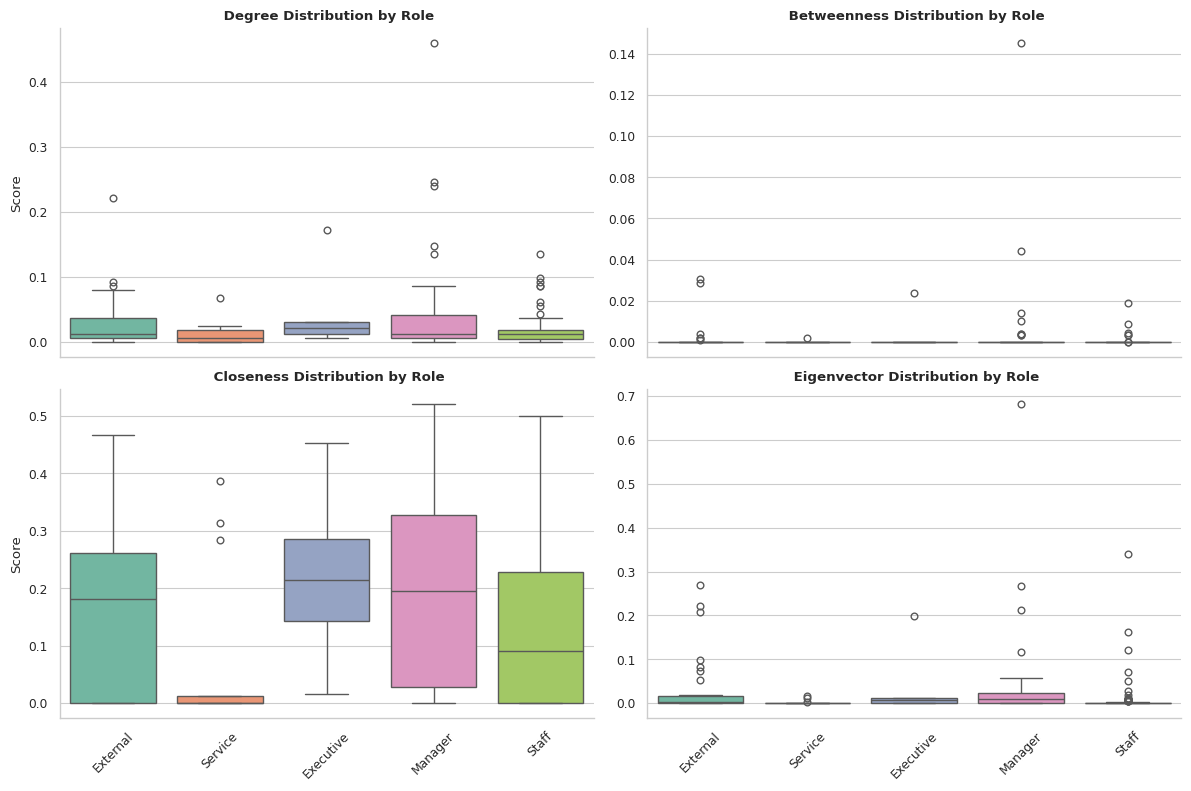

In [13]:
#  Plot Faceted Grid of Boxplots for Categorical Assessment
df_melted = df_metrics.melt(id_vars=['Anonymized_ID', 'Job_Role'],
                            value_vars=metrics,
                            var_name='Centrality_Metric',
                            value_name='Score')

g = sns.FacetGrid(df_melted, col="Centrality_Metric", col_wrap=2, sharey=False, height=4, aspect=1.5)

g.map_dataframe(sns.boxplot, x='Job_Role', y='Score', palette='Set2', hue='Job_Role', legend=False)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    title = ax.get_title().split('=')[1]
    ax.set_title(f"{title} Distribution by Role", fontweight='bold')

plt.tight_layout()
plt.show()

## Outlier Identification & Analysis

We isolate the outliers to identify the specific people whose absence would most disrupt the organization's communication. These specific IDs represent the "single points of failure" or the most influential hidden leaders within the network.

<br>

The analysis identifies **Manager 129** as a critical information broker. They possess a significant amount of control over how information moves between different departments.

<br>

Similarly, **Staff 130** is a high-volume outlier because they manage significantly more connections than the average staff member.  This individual likely serves as a central point of contact or a key operational coordinator moving information between nodes efficiently.

In [14]:
# Identify nodes who serve as critical communication bridges
broker_mask = (df_metrics['Job_Role'] == 'Manager') & (df_metrics['Betweenness'] > 0.10)
manager_broker = df_metrics[broker_mask]

print("Critical Brokers (Betweenness > 0.10):")
print(manager_broker[['Anonymized_ID', 'Job_Role', 'Betweenness', 'Degree']].to_string(index=False))

print("\n" + "="*60 + "\n")

# Identify staff members who possess high volume
staff_mask = (df_metrics['Job_Role'] == 'Staff') & (df_metrics['Degree'] > 0.10)
staff_outliers = df_metrics[staff_mask].sort_values(by='Degree', ascending=False)

print("High-Volume Staff Outliers (Degree > 0.10):")
print(staff_outliers[['Anonymized_ID', 'Job_Role', 'Degree', 'Betweenness']].to_string(index=False))

Critical Brokers (Betweenness > 0.10):
 Anonymized_ID Job_Role  Betweenness   Degree
           129  Manager     0.145289 0.460123


High-Volume Staff Outliers (Degree > 0.10):
 Anonymized_ID Job_Role   Degree  Betweenness
           130    Staff 0.134969     0.008881
